In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

In [3]:
train_df = pd.read_csv("../data/processed/train_final.csv")
test_df = pd.read_csv("../data/processed/test_final.csv")

print(train_df.shape)
print(test_df.shape)

(1486, 7)
(372, 7)


In [4]:
features = [
    "log_pl_orbsmax",
    "log_st_lum",
    "log_pl_rade",
    "log_teq",
    "log_st_teff",
    "log_stellar_flux"
]

X_train = train_df[features]
y_train = train_df["habitable"]

X_test = test_df[features]
y_test = test_df["habitable"]

In [5]:
print(y_train.value_counts())

habitable
0    1478
1       8
Name: count, dtype: int64


In [6]:
train_df.shape

(1486, 7)

In [7]:
test_df.shape

(372, 7)

In [8]:
print(test_df["habitable"].value_counts())

habitable
0    370
1      2
Name: count, dtype: int64


In [9]:
print(train_df.head())
print(test_df.head())

   log_pl_orbsmax  log_st_lum  log_pl_rade   log_teq  log_st_teff  \
0       -0.255128    0.903445    -0.360182  0.531316     0.515772   
1       -0.257927    0.695227    -0.767733  0.476395     0.481507   
2       -0.122958   -0.321166    -0.391518 -0.366665     0.161508   
3       -0.341789    0.298404     1.398775  0.848777     0.871896   
4        3.458908    0.392995     1.099040 -2.636207     0.696510   

   log_stellar_flux  habitable  
0          0.595122          0  
1          0.515846          0  
2         -0.677869          0  
3          1.054154          0  
4         -1.885888          0  
   log_pl_orbsmax  log_st_lum  log_pl_rade   log_teq  log_st_teff  \
0       -0.295167   -0.841653    -1.318503 -0.248592    -0.896215   
1       -0.206028   -0.822152    -0.623542 -0.588329    -1.049192   
2        5.161499   -1.019647     1.196129 -5.353629    -3.294966   
3       -0.332822    0.544322     1.039218  0.859548     1.200465   
4       -0.204441   -0.022023    -1.357912

In [10]:
features = [
    "log_pl_orbsmax",
    "log_st_lum",
    "log_pl_rade",
    "log_teq",
    "log_st_teff",
    "log_stellar_flux"
]

X_train = train_df[features]
y_train = train_df["habitable"]

X_test = test_df[features]
y_test = test_df["habitable"]

print(X_train.shape)
print(X_test.shape)

(1486, 6)
(372, 6)


In [11]:
pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

In [12]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__penalty": ["l2"],
    "model__solver": ["lbfgs"]
}

In [13]:
grid_search = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    scoring="recall",
    cv=5,
    n_jobs=-1
)

In [14]:
grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation Recall:")
print(grid_search.best_score_)

Best Parameters:
{'model__C': 0.01, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}

Best Cross Validation Recall:
1.0


c:\Users\Samyukthaa\exoplanet-habitability-project\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [15]:
best_model = grid_search.best_estimator_

print(best_model)

Pipeline(steps=[('smote', SMOTE(random_state=42)), ('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(C=0.01, max_iter=1000, penalty='l2'))])


In [16]:
from sklearn.metrics import classification_report, confusion_matrix

# predictions
y_pred = best_model.predict(X_test)

# evaluation
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[340  30]
 [  0   2]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.92      0.96       370
           1       0.06      1.00      0.12         2

    accuracy                           0.92       372
   macro avg       0.53      0.96      0.54       372
weighted avg       0.99      0.92      0.95       372



In [17]:
baseline_model = pipeline
tuned_model = best_model

In [18]:
import pandas as pd

# get coefficients from tuned model
coefficients = tuned_model.named_steps['model'].coef_[0]

feature_importance = pd.DataFrame({
    "Feature": features,
    "Coefficient": coefficients
})

feature_importance = feature_importance.sort_values(by="Coefficient", ascending=False)

print(feature_importance)

            Feature  Coefficient
1        log_st_lum    -0.408506
0    log_pl_orbsmax    -0.491031
3           log_teq    -0.694332
5  log_stellar_flux    -0.896463
2       log_pl_rade    -0.920707
4       log_st_teff    -1.209848


In [19]:
feature_importance["Absolute"] = feature_importance["Coefficient"].abs()
feature_importance = feature_importance.sort_values(by="Absolute", ascending=False)

print(feature_importance)

            Feature  Coefficient  Absolute
4       log_st_teff    -1.209848  1.209848
2       log_pl_rade    -0.920707  0.920707
5  log_stellar_flux    -0.896463  0.896463
3           log_teq    -0.694332  0.694332
0    log_pl_orbsmax    -0.491031  0.491031
1        log_st_lum    -0.408506  0.408506


In [20]:
feature_importance_sorted = feature_importance.sort_values(by="Absolute", ascending=False)
feature_importance_sorted

,Feature,Coefficient,Absolute
4,log_st_teff,-1.209848,1.209848
2,log_pl_rade,-0.920707,0.920707
5,log_stellar_flux,-0.896463,0.896463
3,log_teq,-0.694332,0.694332
0,log_pl_orbsmax,-0.491031,0.491031
1,log_st_lum,-0.408506,0.408506


In [21]:
!pip install shap

   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 555.9/555.9 kB 9.3 MB/s  0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ------------- -------------------------- 12.8/38.1 MB 62.0 MB/s eta 0:00:01
   -------------------------- ------------- 25.2/38.1 MB 58.2 MB/s eta 0:00:01
   ---------------------------------------  38.0/38.1 MB 59.1 MB/s eta 0:00:01
   ---------------------------------------- 38.1/38.1 MB 44.4 MB/s  0:00:00
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 2.8/2.8 MB 43.5 MB/s  0:00:00

   ---------------------------------------- 0/6 [tqdm]
   ---------------------------------------- 0/6 [tqdm]
   ---------------------------------------- 0/6 [tqdm]
   ---------------------------------------- 0/6 [tqdm]
   ---------------------------------------- 0/6 [tqdm]
   ---------------------------------------- 0/6 [t


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
import shap

In [23]:
explainer = shap.Explainer(
    tuned_model.named_steps['model'],
    X_train
)

In [24]:
shap_values = explainer(X_test)

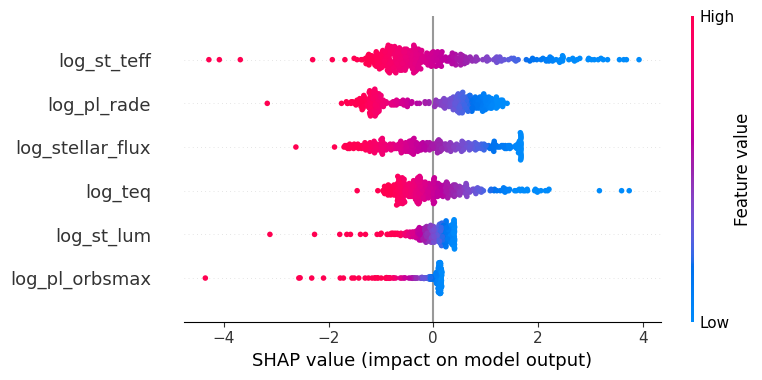

In [25]:
shap.summary_plot(shap_values, X_test)

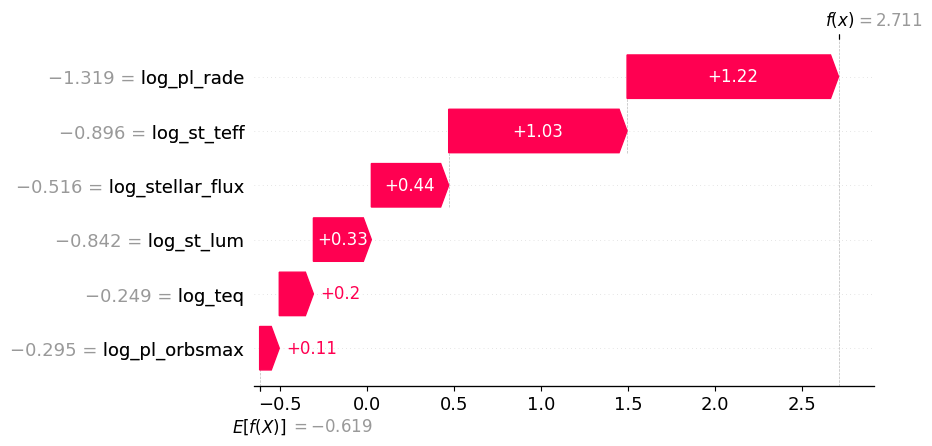

In [26]:
shap.plots.waterfall(shap_values[0])

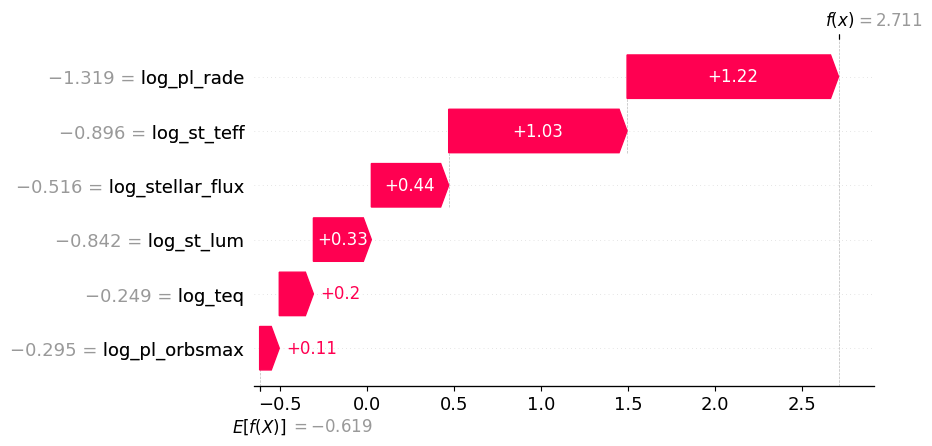

In [27]:
shap.plots.waterfall(shap_values[0])

In [28]:
# get predictions again (just to be safe)
y_pred = tuned_model.predict(X_test)

# add predictions to test dataframe
test_results = test_df.copy()
test_results["prediction"] = y_pred

# false positives: predicted = 1, actual = 0
false_positives = test_results[
    (test_results["prediction"] == 1) & (test_results["habitable"] == 0)
]

print("Number of False Positives:", len(false_positives))
false_positives.head()

Number of False Positives: 30


,log_pl_orbsmax,log_st_lum,log_pl_rade,log_teq,log_st_teff,log_stellar_flux,habitable,prediction
2,5.161499,-1.019647,1.196129,-5.353629,-3.294966,-1.889797,0,1
9,-0.306548,-0.972114,-1.087900,-0.590199,-1.778609,-0.971483,0,1
11,-0.376464,-1.015660,-1.175877,-0.485841,-2.491576,-0.836898,0,1
40,-0.265186,-0.912427,-0.589115,-0.559534,-1.930954,-0.932467,0,1
49,-0.201617,-0.996520,-0.052785,-1.248265,-2.317523,-1.626053,0,1


In [29]:
# true positives: predicted = 1, actual = 1
true_positives = test_results[
    (test_results["prediction"] == 1) & (test_results["habitable"] == 1)
]

print("Number of True Positives:", len(true_positives))
true_positives

Number of True Positives: 2


,log_pl_orbsmax,log_st_lum,log_pl_rade,log_teq,log_st_teff,log_stellar_flux,habitable,prediction
191,0.063992,-0.883436,-1.120823,-1.290203,-1.002000,-1.652154,1,1
348,0.086405,-0.955552,-1.218903,-1.556664,-1.823843,-1.774095,1,1


In [30]:
print("False Positives Mean:\n")
print(false_positives[features].mean())

print("\nTrue Positives Mean:\n")
print(true_positives[features].mean())

False Positives Mean:

log_pl_orbsmax      0.136994
log_st_lum         -0.992098
log_pl_rade        -0.670273
log_teq            -1.235545
log_st_teff        -2.269190
log_stellar_flux   -1.246567
dtype: float64

True Positives Mean:

log_pl_orbsmax      0.075198
log_st_lum         -0.919494
log_pl_rade        -1.169863
log_teq            -1.423433
log_st_teff        -1.412921
log_stellar_flux   -1.713124
dtype: float64


In [31]:
y_probs = tuned_model.predict_proba(X_test)[:, 1]

In [32]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

print("AUC Score:", auc_score)

AUC Score: 0.9743243243243244


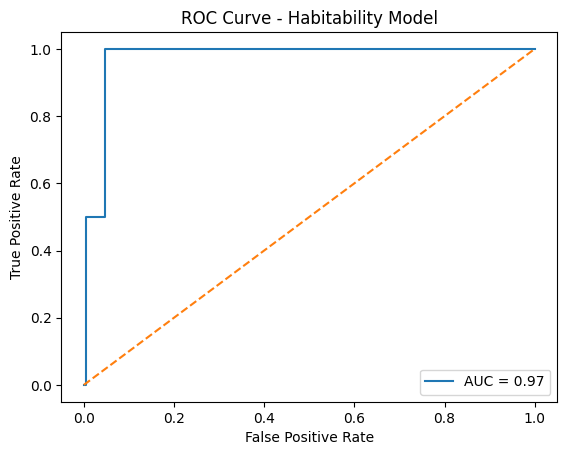

In [33]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")  # random baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Habitability Model")
plt.legend()
plt.show()

In [34]:
import joblib

joblib.dump(tuned_model, "../models/habitability_model.pkl")

['../models/habitability_model.pkl']

In [35]:
model = joblib.load("../models/habitability_model.pkl")